# Proyecto Final: Clasificacion de Textos por Decada

En este notebook desarrollamos una version mas completa del trabajo para la competencia del curso. El objetivo es construir un modelo de machine learning clasico que, dado un fragmento de texto historico, prediga la decada en la que fue escrito.

## Que se mejora en esta version

1. Se analiza mejor el ruido de OCR.
2. Se implementa una limpieza de texto mas fuerte.
3. Se agregan features de estilo para darle mas senales al modelo.
4. Se prueban varios modelos clasicos legales segun el enunciado.
5. Se incorpora validacion mas robusta con `StratifiedKFold` y una seccion de `GridSearchCV`.
6. Se agrega analisis de errores por decada.

## Restriccion importante del enunciado

Todo lo que aparece en este notebook usa modelos clasicos de `scikit-learn`. No se usan redes neuronales, transformers ni tecnicas de deep learning.


## 1. Importacion de librerias


In [1]:
from collections import Counter
from pathlib import Path
import re
import time
import unicodedata

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import LinearSVC

pd.set_option('display.max_colwidth', 180)
pd.set_option('display.max_columns', 50)
plt.style.use('ggplot')

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / 'models'
SUBMISSIONS_DIR = PROJECT_ROOT / 'data' / 'submissions'
MODEL_OUTPUT_DIR = MODELS_DIR if MODELS_DIR.exists() else PROJECT_ROOT
SUBMISSION_OUTPUT_DIR = SUBMISSIONS_DIR if SUBMISSIONS_DIR.exists() else PROJECT_ROOT

PROJECT_ROOT

WindowsPath('C:/Users/userr/Proyecto-Machine_learning')

## Configuracion de ejecucion


Estas banderas permiten controlar el costo computacional del notebook.

- `RUN_FULL_MODEL_COMPARISON`: activa mas modelos y configuraciones.
- `RUN_GRID_SEARCH`: activa una busqueda de hiperparametros con validacion cruzada.
- `RUN_FIVE_SUBMISSIONS`: genera cinco archivos para Kaggle.

Por defecto dejamos la version razonable para que el notebook corra sin quedarse demasiado tiempo congelado en VS Code o Jupyter.


In [2]:
EXECUTION_MODE = 'FULL'  # 'FAST' o 'FULL'
RUN_FULL_MODEL_COMPARISON = EXECUTION_MODE.upper() == 'FULL'
RUN_GRID_SEARCH = True
RUN_FIVE_SUBMISSIONS = False
RANDOM_SEED = 42
GRIDSEARCH_N_JOBS = 1

In [3]:
np.random.seed(RANDOM_SEED)

CV_SPLITS = 5 if RUN_FULL_MODEL_COMPARISON else 3
HOLDOUT_N_SPLITS = 5
ROBUST_CV_TOP_K = 4 if RUN_FULL_MODEL_COMPARISON else 3

WORD_MAX_FEATURES = 140_000 if RUN_FULL_MODEL_COMPARISON else 80_000
CHAR_MAX_FEATURES = 220_000 if RUN_FULL_MODEL_COMPARISON else 120_000
NB_MAX_FEATURES = 90_000 if RUN_FULL_MODEL_COMPARISON else 50_000
HYBRID_WORD_MAX_FEATURES = 50_000 if RUN_FULL_MODEL_COMPARISON else 25_000
HYBRID_CHAR_MAX_FEATURES = 80_000 if RUN_FULL_MODEL_COMPARISON else 40_000

config_df = pd.DataFrame(
    {
        'parameter': [
            'EXECUTION_MODE',
            'RUN_FULL_MODEL_COMPARISON',
            'RUN_GRID_SEARCH',
            'RUN_FIVE_SUBMISSIONS',
            'RANDOM_SEED',
            'HOLDOUT_N_SPLITS',
            'CV_SPLITS',
            'ROBUST_CV_TOP_K',
            'GRIDSEARCH_N_JOBS',
            'WORD_MAX_FEATURES',
            'CHAR_MAX_FEATURES',
            'NB_MAX_FEATURES',
            'HYBRID_WORD_MAX_FEATURES',
            'HYBRID_CHAR_MAX_FEATURES',
            'MODEL_OUTPUT_DIR',
            'SUBMISSION_OUTPUT_DIR',
        ],
        'value': [
            EXECUTION_MODE,
            RUN_FULL_MODEL_COMPARISON,
            RUN_GRID_SEARCH,
            RUN_FIVE_SUBMISSIONS,
            RANDOM_SEED,
            HOLDOUT_N_SPLITS,
            CV_SPLITS,
            ROBUST_CV_TOP_K,
            GRIDSEARCH_N_JOBS,
            WORD_MAX_FEATURES,
            CHAR_MAX_FEATURES,
            NB_MAX_FEATURES,
            HYBRID_WORD_MAX_FEATURES,
            HYBRID_CHAR_MAX_FEATURES,
            str(MODEL_OUTPUT_DIR.relative_to(PROJECT_ROOT) if MODEL_OUTPUT_DIR != PROJECT_ROOT else Path('.')),
            str(SUBMISSION_OUTPUT_DIR.relative_to(PROJECT_ROOT) if SUBMISSION_OUTPUT_DIR != PROJECT_ROOT else Path('.')),
        ],
    }
)
config_df

,parameter,value
0,EXECUTION_MODE,FULL
1,RUN_FULL_MODEL_COMPARISON,True
2,RUN_GRID_SEARCH,True
3,RUN_FIVE_SUBMISSIONS,False
4,RANDOM_SEED,42
5,HOLDOUT_N_SPLITS,5
6,CV_SPLITS,5
7,ROBUST_CV_TOP_K,4
8,GRIDSEARCH_N_JOBS,1
9,WORD_MAX_FEATURES,140000


## 2. Carga de los datos


En la competencia hay dos archivos importantes:

- `train.csv`: contiene `text` y la etiqueta `decade`.
- `eval.csv`: contiene `id` y `text`, pero no trae la respuesta.

Por lo tanto:

- `train.csv` se usa para entrenar y validar.
- `eval.csv` se usa solo para la prediccion final.


In [4]:
train_df = pd.read_csv(PROJECT_ROOT / "data" / "train.csv")
eval_df = pd.read_csv(PROJECT_ROOT / "data" / "eval.csv")

summary_df = pd.DataFrame(
    {
        "dataset": ["train", "eval"],
        "rows": [len(train_df), len(eval_df)],
        "columns": [list(train_df.columns), list(eval_df.columns)],
    }
)
summary_df


,dataset,rows,columns
0,train,31403,"[text, decade]"
1,eval,3490,"[id, text]"


In [5]:
display(train_df.head(3))
display(eval_df.head(3))


,text,decade
0,"\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \r\npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \r\nnes parece que aísilte, O ayuda Calsio...",164
1,"gone. Sus amigos , sus clientes, todo \r\ncuanto le rodea le prueban que es hom- \r\nbre de mucha importancia. Si ve que al- \r\ngunos hombre» plebeyos á fuerza de ser- \r\nvic...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan feratormentados, e \r\nante quien,e quie preguntasles deuan hazer mientras los tormentarf, \r\nvecla.lstitopuzo",157


,id,text
0,0,"P. Si en efta convocación trato folamente de comunicarles los artículos arregla- \r\ndos, y firmados, o de proponerles , qué podrían hacer por fu parte para ..."
1,1,"«Muy santo Padre : Ayer escribiá don Juan Man- \r\ny rique que dijese á vuestra Santidad, ó le escribie- \r\n»se, en cuán bucnos términos quedaban en este \r\nyreino los negoci..."
2,2,"Recibo, otorgado por Diego Gracián a favor de Jerónimo Zurita, de un libro de Casiodoro, titulado \r\nDe Amicitia et Dilectione seu de Caritate Dei, que pertenecía a la cartuja..."


Segun el enunciado, la variable `decade` representa los tres primeros digitos del ano. Por ejemplo, un texto del ano 1572 pertenece a la clase `157`.


## 3. Exploracion inicial


Antes de modelar conviene revisar:

- si hay datos faltantes,
- cuantas clases tiene el problema,
- como se distribuyen las decadas,
- y como se ve el texto historico sin procesar.


In [6]:
exploration_df = pd.DataFrame(
    {
        "dataset": ["train", "eval"],
        "missing_text": [train_df["text"].isna().sum(), eval_df["text"].isna().sum()],
        "missing_target": [train_df["decade"].isna().sum(), None],
        "unique_ids": [None, eval_df["id"].nunique()],
    }
)
exploration_df


,dataset,missing_text,missing_target,unique_ids
0,train,0,0.0,NaN
1,eval,0,NaN,3490.0


In [7]:
class_distribution = train_df["decade"].value_counts().sort_index().rename("count")

print(f"Numero de clases: {train_df['decade'].nunique()}")
print(f"Decada minima: {train_df['decade'].min()}")
print(f"Decada maxima: {train_df['decade'].max()}")

display(class_distribution.to_frame().head())


Numero de clases: 39
Decada minima: 150
Decada maxima: 188


,count
decade,
150,786
151,812
152,785
153,775
154,830


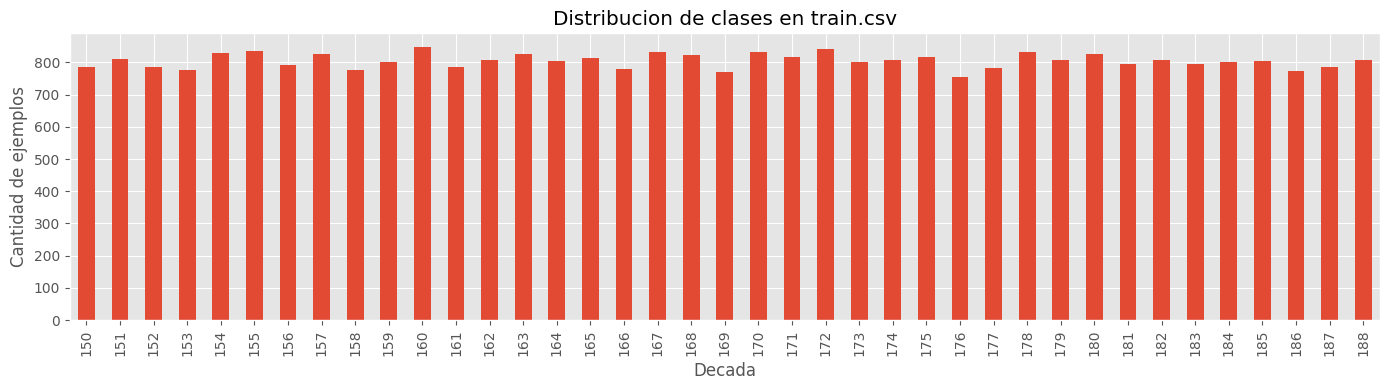

In [8]:
ax = class_distribution.plot(kind="bar", figsize=(14, 4), title="Distribucion de clases en train.csv")
ax.set_xlabel("Decada")
ax.set_ylabel("Cantidad de ejemplos")
plt.tight_layout()
plt.show()


In [9]:
text_stats_df = train_df.assign(
    n_chars=train_df["text"].fillna("").astype(str).str.len(),
    n_words=train_df["text"].fillna("").astype(str).str.split().str.len(),
)

text_stats_df[["n_chars", "n_words"]].describe().T


,count,mean,std,min,25%,50%,75%,max
n_chars,31403.0,530.087316,539.636593,120.0,185.0,321.0,655.0,7480.0
n_words,31403.0,82.283190,82.374190,3.0,30.0,50.0,102.0,1146.0


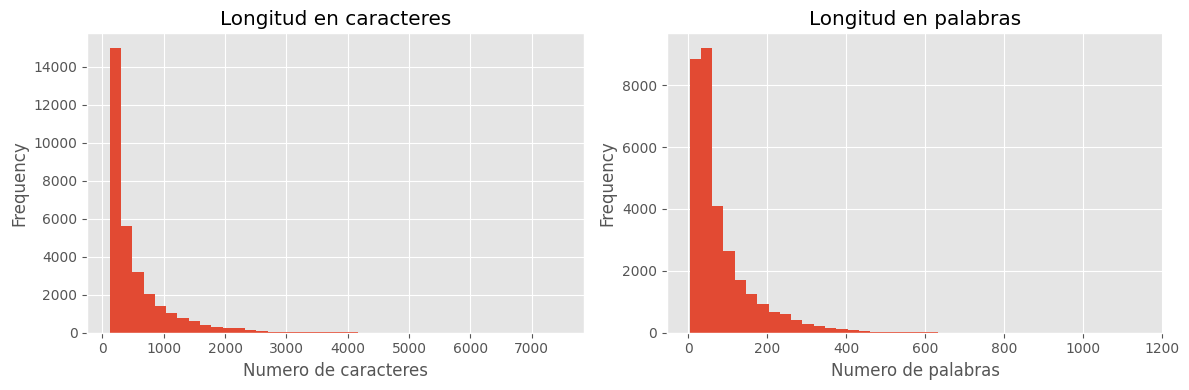

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
text_stats_df["n_chars"].plot.hist(bins=40, ax=axes[0], title="Longitud en caracteres")
text_stats_df["n_words"].plot.hist(bins=40, ax=axes[1], title="Longitud en palabras")
axes[0].set_xlabel("Numero de caracteres")
axes[1].set_xlabel("Numero de palabras")
plt.tight_layout()
plt.show()


## 4. Analisis del ruido de OCR


El texto historico tiene errores de digitalizacion: saltos de linea extra, caracteres raros, tildes mezcladas y separaciones extra?as. Antes de limpiar, conviene mirar ese ruido para no borrar informacion util a ciegas.


In [11]:
def top_special_characters(text_series, sample_size=4000, top_n=25):
    counter = Counter()
    for text in text_series.head(sample_size).fillna("").astype(str):
        for char in text:
            if not char.isalnum() and not char.isspace():
                counter[char] += 1
    return pd.DataFrame(counter.most_common(top_n), columns=["character", "count"])

special_chars_df = top_special_characters(train_df["text"])
special_chars_df


,character,count
0,",",27740
1,.,18116
2,-,9872
3,^,5065
4,:,4766
5,;,2218
6,',2144
7,*,2121
8,(,1446
9,/,1227


In [12]:
sample_examples_df = train_df[["text", "decade"]].sample(3, random_state=42).reset_index(drop=True)
sample_examples_df


,text,decade
0,"— Levanta, hija mia, repuso el supuesto fraile: ¿quién \r\neres, dime, que andas sola por estos despoblados?",183
1,13. Item mando que en la dicha mi villa de Co- \r\nyoacan se edifique y haga un colegio para estudiantes \r\nque estudien teología y derecho canónico par...,184
2,"mente. La fegunda , de lo que oyeron dezir. La ter- \r\ncera , de lo que creen fobre aquel fecho de que les \r\npreguntan, fi es afsi , o non. Pero li e...",175


La idea no es eliminar todo lo raro, sino limpiar lo que claramente es ruido de formato y conservar lo que todavia puede aportar senal historica.


## 5. Comparacion de estrategias de limpieza


En lugar de asumir que "mas limpieza" siempre ayuda, vamos a comparar dos estrategias:

1. `light`: corrige ruido de formato, normaliza unicode y conserva la mayor cantidad posible de senal historica.
2. `aggressive`: ademas de lo anterior, quita acentos, filtra caracteres con mas fuerza y elimina boilerplate muy repetido cuando aparece.

La comparacion visual se hace aqui y la comparacion cuantitativa reaparece mas adelante con el mismo tipo de modelo para no duplicar codigo antes de construir las pipelines.

En los experimentos locales, la limpieza `light` dio mejor score que la agresiva. La razon probable es que, en textos historicos, algunas variaciones ortograficas y graficas si aportan informacion sobre la decada.

Por eso el notebook deja `light` como estrategia por defecto para modelar, y `aggressive` queda como comparacion metodologica.

In [13]:
OCR_BASIC_TRANSLATION_TABLE = str.maketrans(
    {
        '\r': ' ',
        '\n': ' ',
        '\t': ' ',
        '\u00a0': ' ',
        '\u2013': '-',
        '\u2014': '-',
        '\u2018': "'",
        '\u2019': "'",
        '\u201c': '"',
        '\u201d': '"',
    }
)

GOOGLE_BOOKS_BOILERPLATE_PATTERNS = [
    re.compile(r'google is proud to partner with libraries to digitize public domain materials and make them widely accessible\.?', flags=re.IGNORECASE),
    re.compile(r'this is a digital copy of a book that was preserved for generations on library shelves before it was carefully scanned by google.*?(?=google is proud|it has survived|$)', flags=re.IGNORECASE),
    re.compile(r'it has survived long enough for the copyright to expire and the book to enter the public domain\.?', flags=re.IGNORECASE),
    re.compile(r'make non-commercial use of the files.*?(?=maintain attribution|keep it legal|$)', flags=re.IGNORECASE),
    re.compile(r'maintain attribution.*?(?=keep it legal|$)', flags=re.IGNORECASE),
    re.compile(r'keep it legal.*?copyright infringement liability can be quite severe\.?', flags=re.IGNORECASE),
    re.compile(r'ha sobrevivido tantos anos como para que los derechos de autor hayan expirado y el libro pase a ser de dominio publico\.?', flags=re.IGNORECASE),
    re.compile(r'mantengase siempre dentro de la legalidad.*?derechos de autor puede ser muy grave\.?', flags=re.IGNORECASE),
    re.compile(r'haga un uso exclusivamente no comercial de estos archivos.*?(?=mantenga la atribucion|$)', flags=re.IGNORECASE),
]


def strip_accents(text):
    text = unicodedata.normalize('NFKD', text)
    return ''.join(char for char in text if not unicodedata.combining(char))


def remove_known_boilerplate(text):
    accentless_text = strip_accents(text)
    for pattern in GOOGLE_BOOKS_BOILERPLATE_PATTERNS:
        accentless_text = pattern.sub(' ', accentless_text)
    accentless_text = re.sub(r'\s+', ' ', accentless_text)
    return accentless_text.strip()


def normalize_ocr_text_light(text):
    text = '' if pd.isna(text) else str(text)
    text = text.translate(OCR_BASIC_TRANSLATION_TABLE)
    text = re.sub(r'(?<=\w)[-~?]+\s+(?=\w)', '', text)
    text = ''.join(char for char in text if char.isprintable())
    text = unicodedata.normalize('NFKC', text)
    text = re.sub(r'[\u200b\u200c\u200d\ufeff]', ' ', text)
    text = re.sub(r'[_*=`]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()


def normalize_ocr_text_aggressive(text):
    text = normalize_ocr_text_light(text)
    text = remove_known_boilerplate(text)
    text = re.sub(r'[^0-9a-z.,;:!?()/%\- ]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def normalize_ocr_text(text):
    return normalize_ocr_text_light(text)


def clean_text_series(text_series, strategy='light'):
    cleaners = {
        'light': normalize_ocr_text_light,
        'aggressive': normalize_ocr_text_aggressive,
    }
    cleaner = cleaners[strategy]
    return text_series.fillna('').astype(str).apply(cleaner)


train_df['text_clean_light'] = clean_text_series(train_df['text'], strategy='light')
train_df['text_clean_aggressive'] = clean_text_series(train_df['text'], strategy='aggressive')
train_df['text_clean'] = train_df['text_clean_light']

eval_df['text_clean_light'] = clean_text_series(eval_df['text'], strategy='light')
eval_df['text_clean_aggressive'] = clean_text_series(eval_df['text'], strategy='aggressive')
eval_df['text_clean'] = eval_df['text_clean_light']

comparison_preview_df = train_df[['text']].head(3).copy()
comparison_preview_df['clean_light'] = clean_text_series(comparison_preview_df['text'], strategy='light')
comparison_preview_df['clean_aggressive'] = clean_text_series(comparison_preview_df['text'], strategy='aggressive')
display(comparison_preview_df)

,text,clean_light,clean_aggressive
0,"\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \r\npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \r\nnes parece que aísilte, O ayuda Calsio...","honorarias ¡jubiladas. 57 dit.ad pontem de poreft.proreg.118,3, $.9.m.-70 pag.4.1. 3 ste ph.gratian. difcept.291, áqu len nes parece que aísilte, o ayuda calsiodoro lib,6.epuft...","honorarias jubiladas. 57 dit.ad pontem de poreft.proreg.118,3, .9.m.-70 pag.4.1. 3 ste ph.gratian. difcept.291, aqu len nes parece que aisilte, o ayuda calsiodoro lib,6.epuft.s..."
1,"gone. Sus amigos , sus clientes, todo \r\ncuanto le rodea le prueban que es hom- \r\nbre de mucha importancia. Si ve que al- \r\ngunos hombre» plebeyos á fuerza de ser- \r\nvic...","gone. sus amigos , sus clientes, todo cuanto le rodea le prueban que es hombre de mucha importancia. si ve que algunos hombre» plebeyos á fuerza de servicios y de hazañas se el...","gone. sus amigos , sus clientes, todo cuanto le rodea le prueban que es hombre de mucha importancia. si ve que algunos hombre plebeyos a fuerza de servicios y de hazanas se ele..."
2,"Prefosen quemanera,e per qualesfolpechas deuan feratormentados, e \r\nante quien,e quie preguntasles deuan hazer mientras los tormentarf, \r\nvecla.lstitopuzo","prefosen quemanera,e per qualesfolpechas deuan feratormentados, e ante quien,e quie preguntasles deuan hazer mientras los tormentarf, vecla.lstitopuzo","prefosen quemanera,e per qualesfolpechas deuan feratormentados, e ante quien,e quie preguntasles deuan hazer mientras los tormentarf, vecla.lstitopuzo"


Podemos comparar visualmente el antes y el despues con las dos estrategias. La limpieza ligera se queda como default porque conserva mejor la senal util del OCR historico.


## 6. Que son las features y cuales vamos a usar


En machine learning, una *feature* es una caracteristica numerica que el modelo puede usar como senal para tomar decisiones.

En texto, la representacion principal suele venir de `TF-IDF`, pero tambien podemos agregar informacion de estilo. En este proyecto vamos a construir estas features:

| Feature | Que mide | Por que podria ayudar |
| --- | --- | --- |
| `n_chars` | numero de caracteres | algunas epocas tienen textos mas largos o mas compactos |
| `n_words` | numero de palabras | el estilo discursivo cambia con el tiempo |
| `avg_word_length` | promedio de longitud de palabra | algunas variantes historicas usan palabras mas largas o abreviadas |
| `punctuation_ratio` | proporcion de signos `.,;:!?` | la puntuacion cambia entre siglos y fuentes |
| `digit_ratio` | proporcion de digitos | ciertos tipos documentales incluyen mas fechas, numeraciones o referencias |
| `uppercase_ratio` | proporcion de mayusculas | algunos textos tienen convenciones editoriales distintas |
| `unique_char_ratio` | diversidad de caracteres | captura variedad grafica y ruido |
| `line_break_ratio` | cantidad relativa de saltos de linea originales | ayuda a detectar estructura del OCR |
| `short_token_ratio` | proporcion de tokens muy cortos | ayuda a capturar abreviaturas, cortes y ruido OCR |

La idea es que estas features no reemplazan al TF-IDF: lo complementan.

In [14]:
TEXT_COLUMN_BY_STRATEGY = {
    'light': 'text_clean_light',
    'aggressive': 'text_clean_aggressive',
}

STYLE_FEATURE_COLUMNS = [
    'n_chars',
    'n_words',
    'avg_word_length',
    'punctuation_ratio',
    'digit_ratio',
    'uppercase_ratio',
    'unique_char_ratio',
    'line_break_ratio',
    'short_token_ratio',
]


def build_style_feature_frame(text_series):
    raw = text_series.fillna('').astype(str)
    clean_light = raw.apply(normalize_ocr_text_light)
    clean_aggressive = raw.apply(normalize_ocr_text_aggressive)
    tokens = clean_light.str.split()

    raw_len = raw.str.len().clip(lower=1).astype(float)

    feature_df = pd.DataFrame(index=text_series.index)
    feature_df['text_clean_light'] = clean_light
    feature_df['text_clean_aggressive'] = clean_aggressive
    feature_df['text_clean'] = clean_light
    feature_df['n_chars'] = clean_light.str.len().astype(float)
    feature_df['n_words'] = tokens.str.len().astype(float)
    feature_df['avg_word_length'] = tokens.apply(lambda words: float(np.mean([len(word) for word in words])) if words else 0.0)
    feature_df['punctuation_ratio'] = raw.str.count(r'[.,;:!?]') / raw_len
    feature_df['digit_ratio'] = raw.str.count(r'\d') / raw_len
    feature_df['uppercase_ratio'] = raw.apply(lambda text: sum(char.isupper() for char in text) / max(len(text), 1))
    feature_df['unique_char_ratio'] = raw.apply(lambda text: len(set(text)) / max(len(text), 1))
    feature_df['line_break_ratio'] = raw.str.count(r'[\r\n]') / raw_len
    feature_df['short_token_ratio'] = tokens.apply(lambda words: float(np.mean([len(word) <= 2 for word in words])) if words else 0.0)
    return feature_df


def add_engineered_features(df):
    return build_style_feature_frame(df['text'])


feature_preview_df = add_engineered_features(train_df[['text']].head(5))
feature_preview_df

,text_clean_light,text_clean_aggressive,text_clean,n_chars,n_words,avg_word_length,punctuation_ratio,digit_ratio,uppercase_ratio,unique_char_ratio,line_break_ratio,short_token_ratio
0,"honorarias ¡jubiladas. 57 dit.ad pontem de poreft.proreg.118,3, $.9.m.-70 pag.4.1. 3 ste ph.gratian. difcept.291, áqu len nes parece que aísilte, o ayuda calsiodoro lib,6.epuft...","honorarias jubiladas. 57 dit.ad pontem de poreft.proreg.118,3, .9.m.-70 pag.4.1. 3 ste ph.gratian. difcept.291, aqu len nes parece que aisilte, o ayuda calsiodoro lib,6.epuft.s...","honorarias ¡jubiladas. 57 dit.ad pontem de poreft.proreg.118,3, $.9.m.-70 pag.4.1. 3 ste ph.gratian. difcept.291, áqu len nes parece que aísilte, o ayuda calsiodoro lib,6.epuft...",209.0,28.0,6.500000,0.093750,0.084821,0.066964,0.236607,0.044643,0.178571
1,"gone. sus amigos , sus clientes, todo cuanto le rodea le prueban que es hombre de mucha importancia. si ve que algunos hombre» plebeyos á fuerza de servicios y de hazañas se el...","gone. sus amigos , sus clientes, todo cuanto le rodea le prueban que es hombre de mucha importancia. si ve que algunos hombre plebeyos a fuerza de servicios y de hazanas se ele...","gone. sus amigos , sus clientes, todo cuanto le rodea le prueban que es hombre de mucha importancia. si ve que algunos hombre» plebeyos á fuerza de servicios y de hazañas se el...",334.0,61.0,4.491803,0.019284,0.000000,0.005510,0.107438,0.044077,0.377049
2,"prefosen quemanera,e per qualesfolpechas deuan feratormentados, e ante quien,e quie preguntasles deuan hazer mientras los tormentarf, vecla.lstitopuzo","prefosen quemanera,e per qualesfolpechas deuan feratormentados, e ante quien,e quie preguntasles deuan hazer mientras los tormentarf, vecla.lstitopuzo","prefosen quemanera,e per qualesfolpechas deuan feratormentados, e ante quien,e quie preguntasles deuan hazer mientras los tormentarf, vecla.lstitopuzo",150.0,17.0,7.882353,0.032258,0.000000,0.006452,0.167742,0.025806,0.058824
3,"caistro el m a y o r a i .] del apellido de cañroíe valió don luis enefta. metáfora, para el nombre que fupo ne de caiftro. mayoral fe llama entre los ganaderos el que tiene el...","caistro el m a y o r a i . del apellido de canroie valio don luis enefta. metafora, para el nombre que fupo ne de caiftro. mayoral fe llama entre los ganaderos el que tiene el ...","caistro el m a y o r a i .] del apellido de cañroíe valió don luis enefta. metáfora, para el nombre que fupo ne de caiftro. mayoral fe llama entre los ganaderos el que tiene el...",259.0,53.0,3.905660,0.022293,0.000000,0.028662,0.111465,0.025478,0.377358
4,"los que panden macho ; y otros en la fu ña abundan¬ cia , íiempre viuen como mendigos. la lana aun en el edito fagrado compite con el sol luzimieutos,' pues a los dos los llama...","los que panden macho ; y otros en la fu na abundan cia , iiempre viuen como mendigos. la lana aun en el edito fagrado compite con el sol luzimieutos, pues a los dos los llama m...","los que panden macho ; y otros en la fu ña abundan¬ cia , íiempre viuen como mendigos. la lana aun en el edito fagrado compite con el sol luzimieutos,' pues a los dos los llama...",952.0,170.0,4.605882,0.019811,0.000861,0.021533,0.049957,0.062016,0.305882


Estas features salen del texto mismo. El modelo las recibe como columnas numericas adicionales junto con los vectores TF-IDF.


## 7. Separacion en entrenamiento y validacion


Primero dejamos un conjunto de validacion externa para comparar modelos de forma rapida. Como detectamos textos repetidos despues de la normalizacion OCR, el holdout se construye con `StratifiedGroupKFold` para que los duplicados no queden repartidos entre entrenamiento y validacion. Mas adelante reutilizamos la misma idea para una validacion mas robusta por folds.

In [15]:
X_full = train_df[['text']].copy()
y_full = train_df['decade'].copy()
X_eval = eval_df[['text']].copy()

text_group_keys = clean_text_series(train_df['text'], strategy='light')
duplicate_groups_df = (
    pd.DataFrame(
        {
            'group_key': text_group_keys,
            'decade': y_full.values,
            'text_preview': train_df['text'].fillna('').astype(str).str.slice(0, 120),
        }
    )
    .groupby('group_key', dropna=False)
    .agg(rows=('decade', 'size'), unique_labels=('decade', 'nunique'), example_preview=('text_preview', 'first'))
    .reset_index()
)
duplicate_groups_df = duplicate_groups_df.loc[duplicate_groups_df['rows'] > 1].sort_values(['unique_labels', 'rows'], ascending=False).reset_index(drop=True)

duplicate_summary_df = pd.DataFrame(
    {
        'metric': [
            'normalized_duplicate_groups',
            'rows_inside_duplicate_groups',
            'duplicate_groups_with_conflicting_labels',
            'max_rows_in_duplicate_group',
        ],
        'value': [
            int(len(duplicate_groups_df)),
            int(duplicate_groups_df['rows'].sum()) if len(duplicate_groups_df) else 0,
            int((duplicate_groups_df['unique_labels'] > 1).sum()) if len(duplicate_groups_df) else 0,
            int(duplicate_groups_df['rows'].max()) if len(duplicate_groups_df) else 0,
        ],
    }
)
display(duplicate_summary_df)
display(duplicate_groups_df[['rows', 'unique_labels', 'example_preview']].head(10))

holdout_splitter = StratifiedGroupKFold(n_splits=HOLDOUT_N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
train_idx, valid_idx = next(holdout_splitter.split(X_full, y_full, groups=text_group_keys))

X_train = X_full.iloc[train_idx].reset_index(drop=True)
X_valid = X_full.iloc[valid_idx].reset_index(drop=True)
y_train = y_full.iloc[train_idx].reset_index(drop=True)
y_valid = y_full.iloc[valid_idx].reset_index(drop=True)
train_groups = text_group_keys.iloc[train_idx].reset_index(drop=True)
valid_groups = text_group_keys.iloc[valid_idx].reset_index(drop=True)
shared_group_count = len(set(train_groups) & set(valid_groups))

split_summary_df = pd.DataFrame(
    {
        'split': ['train', 'validation'],
        'rows': [len(X_train), len(X_valid)],
        'proportion': [len(X_train) / len(X_full), len(X_valid) / len(X_full)],
        'unique_group_keys': [train_groups.nunique(), valid_groups.nunique()],
        'shared_groups_with_other_split': [shared_group_count, shared_group_count],
    }
)
split_summary_df

,metric,value
0,normalized_duplicate_groups,49
1,rows_inside_duplicate_groups,110
2,duplicate_groups_with_conflicting_labels,17
3,max_rows_in_duplicate_group,4


,rows,unique_labels,example_preview
0,4,4,It has survived long enough for the copyright to expire and the book to enter the public domain. A public domain book is
1,3,3,"+ Keep it legal Whatever your use, remember that you are lesponsible for ensuring that what you are doing is legal. Do n"
2,3,3,"+ Maintain attribution The Google ""watermark"" you see on each file is essential for informing people about this project"
3,3,3,"+ Make non-commercial use of the files We designed Google Book Search for use by individuáis, and we request that you us"
4,3,3,"+ Manténgase siempre dentro de la legalidad Sea cual sea el uso que haga de estos materiales, recuerde que es responsabl"
5,3,3,Ha sobrevivido tantos años como para que los derechos de autor hayan expirado y el libro pase a ser de dominio público.
6,3,3,"Marks, notations and other maiginalia present in the original volume will appear in this file - a reminder of this book'"
7,3,3,This is a digital copy of a book that was prcscrvod for gcncrations on library shclvcs bcforc it was carcfully scannod b
8,3,2,"puertas hacia el pasado, suponen un patrimonio histórico, cultural y de conocimientos que, a menudo, resulta difícil de"
9,2,2,+ Haga un uso exclusivamente no comercial de estos archivos Hemos diseñado la Búsqueda de libros de Google para el uso d


,split,rows,proportion,unique_group_keys,shared_groups_with_other_split
0,train,25122,0.799987,25073,0
1,validation,6281,0.200013,6269,0


## 8. Construccion de pipelines de modelado


Para mantener el flujo limpio, vamos a usar pipelines de `scikit-learn`. La ventaja es que el preprocesamiento, la vectorizacion y el clasificador quedan unidos en un solo objeto entrenable y guardable con `joblib`.


In [16]:
def make_preprocessor(
    text_mode='word',
    cleaning_strategy='light',
    include_style_features=False,
    word_ngram_range=(1, 2),
    char_ngram_range=(2, 5),
    char_analyzer='char',
    word_min_df=2,
    word_max_df=0.98,
    word_sublinear_tf=True,
    word_binary=False,
    word_max_features=None,
    char_min_df=2,
    char_binary=False,
    char_max_features=None,
):
    transformers = []
    text_column = TEXT_COLUMN_BY_STRATEGY[cleaning_strategy]

    if text_mode in {'word', 'word_char'}:
        transformers.append(
            (
                'word_tfidf',
                TfidfVectorizer(
                    analyzer='word',
                    ngram_range=word_ngram_range,
                    min_df=word_min_df,
                    max_df=word_max_df,
                    max_features=word_max_features if word_max_features is not None else WORD_MAX_FEATURES,
                    sublinear_tf=word_sublinear_tf,
                    binary=word_binary,
                ),
                text_column,
            )
        )

    if text_mode in {'char', 'char_wb', 'word_char'}:
        effective_char_analyzer = 'char_wb' if text_mode == 'char_wb' else char_analyzer
        if char_max_features is None:
            char_max_features = CHAR_MAX_FEATURES if text_mode in {'char', 'char_wb'} else HYBRID_CHAR_MAX_FEATURES

        transformers.append(
            (
                'char_tfidf',
                TfidfVectorizer(
                    analyzer=effective_char_analyzer,
                    ngram_range=char_ngram_range,
                    min_df=char_min_df,
                    max_features=char_max_features,
                    sublinear_tf=True,
                    binary=char_binary,
                ),
                text_column,
            )
        )

    if include_style_features:
        transformers.append(
            (
                'style',
                StandardScaler(with_mean=False),
                STYLE_FEATURE_COLUMNS,
            )
        )

    return ColumnTransformer(transformers=transformers, remainder='drop', sparse_threshold=1.0)


def build_pipeline(
    text_mode,
    classifier,
    cleaning_strategy='light',
    include_style_features=False,
    word_ngram_range=(1, 2),
    char_ngram_range=(2, 5),
    char_analyzer='char',
    word_min_df=2,
    word_max_df=0.98,
    word_sublinear_tf=True,
    word_binary=False,
    word_max_features=None,
    char_min_df=2,
    char_binary=False,
    char_max_features=None,
):
    return Pipeline(
        steps=[
            ('feature_builder', FunctionTransformer(add_engineered_features, validate=False)),
            (
                'preprocessor',
                make_preprocessor(
                    text_mode=text_mode,
                    cleaning_strategy=cleaning_strategy,
                    include_style_features=include_style_features,
                    word_ngram_range=word_ngram_range,
                    char_ngram_range=char_ngram_range,
                    char_analyzer=char_analyzer,
                    word_min_df=word_min_df,
                    word_max_df=word_max_df,
                    word_sublinear_tf=word_sublinear_tf,
                    word_binary=word_binary,
                    word_max_features=word_max_features,
                    char_min_df=char_min_df,
                    char_binary=char_binary,
                    char_max_features=char_max_features,
                ),
            ),
            ('classifier', classifier),
        ]
    )


def evaluate_model(model, X_train, y_train, X_valid, y_valid):
    start = time.time()
    model.fit(X_train, y_train)
    predictions = model.predict(X_valid)
    return {
        'model': model,
        'predictions': predictions,
        'accuracy': accuracy_score(y_valid, predictions),
        'macro_f1': f1_score(y_valid, predictions, average='macro'),
        'elapsed_seconds': time.time() - start,
    }


def is_better_result(candidate_result, incumbent_result):
    if candidate_result['accuracy'] > incumbent_result['accuracy']:
        return True
    if candidate_result['accuracy'] < incumbent_result['accuracy']:
        return False
    return candidate_result['macro_f1'] >= incumbent_result['macro_f1']


def run_grouped_cv(model, X, y, groups, n_splits):
    cv_strategy = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    fold_rows = []

    for fold_idx, (fold_train_idx, fold_valid_idx) in enumerate(cv_strategy.split(X, y, groups=groups), start=1):
        fold_model = clone(model)
        start = time.time()
        fold_model.fit(X.iloc[fold_train_idx], y.iloc[fold_train_idx])
        fold_predictions = fold_model.predict(X.iloc[fold_valid_idx])
        fold_rows.append(
            {
                'fold': fold_idx,
                'accuracy': accuracy_score(y.iloc[fold_valid_idx], fold_predictions),
                'macro_f1': f1_score(y.iloc[fold_valid_idx], fold_predictions, average='macro'),
                'elapsed_seconds': time.time() - start,
            }
        )

    fold_results_df = pd.DataFrame(fold_rows)
    summary = {
        'cv_accuracy_mean': fold_results_df['accuracy'].mean(),
        'cv_accuracy_std': fold_results_df['accuracy'].std(ddof=0),
        'cv_macro_f1_mean': fold_results_df['macro_f1'].mean(),
        'cv_macro_f1_std': fold_results_df['macro_f1'].std(ddof=0),
        'cv_elapsed_seconds_mean': fold_results_df['elapsed_seconds'].mean(),
    }
    return fold_results_df, summary

## 9. Modelo baseline


El baseline sera un modelo sencillo:

- TF-IDF de palabras.
- LogisticRegression.

Esto nos da una referencia clara para evaluar si las mejoras realmente ayudan.


In [17]:
def build_baseline_model():
    return build_pipeline(
        text_mode='word',
        classifier=LogisticRegression(max_iter=1200, solver='saga', random_state=RANDOM_SEED),
        cleaning_strategy='light',
        include_style_features=False,
        word_ngram_range=(1, 1),
        word_min_df=2,
        word_max_df=0.98,
        word_sublinear_tf=True,
        word_binary=False,
        word_max_features=min(80_000, WORD_MAX_FEATURES),
    )


baseline_result = evaluate_model(build_baseline_model(), X_train, y_train, X_valid, y_valid)

baseline_df = pd.DataFrame(
    [
        {
            'model_name': 'baseline_word_logreg',
            'model_family': 'word_logreg',
            'accuracy': baseline_result['accuracy'],
            'macro_f1': baseline_result['macro_f1'],
            'elapsed_seconds': baseline_result['elapsed_seconds'],
        }
    ]
)
baseline_df

,model_name,model_family,accuracy,macro_f1,elapsed_seconds
0,baseline_word_logreg,word_logreg,0.212864,0.199464,18.623206


## 10. Prueba de otros modelos clasicos


Todos los modelos de esta seccion son legales segun el documento porque usan `scikit-learn` y no involucran deep learning.

La comparacion queda enfocada en lo que realmente mostro potencial en validacion local:

- `LinearSVC` con n-gramas de caracteres planos (`analyzer="char"`).
- `LinearSVC` con n-gramas `char_wb` como referencia cercana.
- `MultinomialNB` como baseline rapido de texto.
- una version combinada de palabras + caracteres + features de estilo para contrastar si meter mas senales ayuda de verdad.


In [18]:
def build_word_bigram_logreg_model():
    return build_pipeline(
        text_mode='word',
        classifier=LogisticRegression(max_iter=1500, solver='saga', C=2.0, random_state=RANDOM_SEED),
        cleaning_strategy='light',
        include_style_features=False,
        word_ngram_range=(1, 2),
        word_min_df=2,
        word_max_df=0.97,
        word_sublinear_tf=True,
        word_binary=False,
        word_max_features=WORD_MAX_FEATURES,
    )


def build_word_trigram_logreg_model():
    return build_pipeline(
        text_mode='word',
        classifier=LogisticRegression(max_iter=1500, solver='saga', C=2.0, random_state=RANDOM_SEED),
        cleaning_strategy='light',
        include_style_features=False,
        word_ngram_range=(1, 3),
        word_min_df=3,
        word_max_df=0.96,
        word_sublinear_tf=True,
        word_binary=False,
        word_max_features=WORD_MAX_FEATURES,
    )


def build_char_plain_linsvc_c04_model():
    return build_pipeline(
        text_mode='char',
        classifier=LinearSVC(C=0.4, max_iter=4000),
        cleaning_strategy='light',
        include_style_features=False,
        char_ngram_range=(2, 5),
        char_analyzer='char',
        char_min_df=3,
        char_max_features=CHAR_MAX_FEATURES,
    )


def build_char_plain_linsvc_c06_model():
    return build_pipeline(
        text_mode='char',
        classifier=LinearSVC(C=0.6, max_iter=4000),
        cleaning_strategy='light',
        include_style_features=False,
        char_ngram_range=(2, 5),
        char_analyzer='char',
        char_min_df=2,
        char_max_features=CHAR_MAX_FEATURES,
    )


def build_char_plain_linsvc_aggressive_model():
    return build_pipeline(
        text_mode='char',
        classifier=LinearSVC(C=0.4, max_iter=4000),
        cleaning_strategy='aggressive',
        include_style_features=False,
        char_ngram_range=(2, 5),
        char_analyzer='char',
        char_min_df=3,
        char_max_features=CHAR_MAX_FEATURES,
    )


def build_char_wb_linsvc_model():
    return build_pipeline(
        text_mode='char_wb',
        classifier=LinearSVC(C=0.8, max_iter=4000),
        cleaning_strategy='light',
        include_style_features=False,
        char_ngram_range=(3, 5),
        char_max_features=CHAR_MAX_FEATURES,
    )


def build_char_plain_sgd_model():
    return build_pipeline(
        text_mode='char',
        classifier=SGDClassifier(loss='hinge', alpha=1e-5, max_iter=2500, tol=1e-3, random_state=RANDOM_SEED),
        cleaning_strategy='light',
        include_style_features=False,
        char_ngram_range=(2, 5),
        char_analyzer='char',
        char_min_df=2,
        char_max_features=CHAR_MAX_FEATURES,
    )


def build_char_plain_ridge_model():
    return build_pipeline(
        text_mode='char',
        classifier=RidgeClassifier(alpha=1.0),
        cleaning_strategy='light',
        include_style_features=False,
        char_ngram_range=(2, 5),
        char_analyzer='char',
        char_min_df=2,
        char_max_features=CHAR_MAX_FEATURES,
    )


def build_word_complement_nb_model():
    return build_pipeline(
        text_mode='word',
        classifier=ComplementNB(alpha=0.5),
        cleaning_strategy='light',
        include_style_features=False,
        word_ngram_range=(1, 2),
        word_min_df=2,
        word_max_df=0.98,
        word_sublinear_tf=False,
        word_binary=False,
        word_max_features=NB_MAX_FEATURES,
    )


def build_word_char_style_linsvc_model():
    return build_pipeline(
        text_mode='word_char',
        classifier=LinearSVC(C=0.5, max_iter=4000),
        cleaning_strategy='light',
        include_style_features=True,
        word_ngram_range=(1, 2),
        word_min_df=3,
        word_max_df=0.97,
        word_sublinear_tf=True,
        word_binary=False,
        word_max_features=HYBRID_WORD_MAX_FEATURES,
        char_ngram_range=(3, 5),
        char_analyzer='char_wb',
        char_min_df=2,
        char_max_features=HYBRID_CHAR_MAX_FEATURES,
    )


candidate_builders = {
    'baseline_word_logreg': build_baseline_model,
    'word_bigram_logreg': build_word_bigram_logreg_model,
    'word_trigram_logreg': build_word_trigram_logreg_model,
    'char_plain_linsvc_c04': build_char_plain_linsvc_c04_model,
    'char_plain_linsvc_c06': build_char_plain_linsvc_c06_model,
    'char_plain_linsvc_aggressive': build_char_plain_linsvc_aggressive_model,
    'char_wb_linsvc_c08': build_char_wb_linsvc_model,
    'char_plain_sgd': build_char_plain_sgd_model,
    'char_plain_ridge': build_char_plain_ridge_model,
    'word_complement_nb': build_word_complement_nb_model,
    'word_char_style_linsvc': build_word_char_style_linsvc_model,
}

candidate_family_map = {
    'baseline_word_logreg': 'word_logreg',
    'word_bigram_logreg': 'word_logreg',
    'word_trigram_logreg': 'word_logreg',
    'char_plain_linsvc_c04': 'char_plain_linsvc',
    'char_plain_linsvc_c06': 'char_plain_linsvc',
    'char_plain_linsvc_aggressive': 'char_plain_linsvc_aggressive',
    'char_wb_linsvc_c08': 'char_wb_linsvc',
    'char_plain_sgd': 'char_plain_sgd',
    'char_plain_ridge': 'char_plain_ridge',
    'word_complement_nb': 'word_nb',
    'word_char_style_linsvc': 'word_char_linsvc',
}

fast_candidate_names = [
    'baseline_word_logreg',
    'char_plain_linsvc_c04',
    'char_wb_linsvc_c08',
    'char_plain_sgd',
    'word_complement_nb',
]

full_candidate_names = [
    'baseline_word_logreg',
    'word_bigram_logreg',
    'word_trigram_logreg',
    'char_plain_linsvc_c04',
    'char_plain_linsvc_c06',
    'char_plain_linsvc_aggressive',
    'char_wb_linsvc_c08',
    'char_plain_sgd',
    'char_plain_ridge',
    'word_complement_nb',
    'word_char_style_linsvc',
]

selected_candidate_names = full_candidate_names if RUN_FULL_MODEL_COMPARISON else fast_candidate_names
print('Modelos a evaluar:', selected_candidate_names)

Modelos a evaluar: ['baseline_word_logreg', 'word_bigram_logreg', 'word_trigram_logreg', 'char_plain_linsvc_c04', 'char_plain_linsvc_c06', 'char_plain_linsvc_aggressive', 'char_wb_linsvc_c08', 'char_plain_sgd', 'char_plain_ridge', 'word_complement_nb', 'word_char_style_linsvc']


In [19]:
validation_runs = {}
comparison_rows = []

for model_name in selected_candidate_names:
    print(f'Evaluando {model_name}...', flush=True)
    result = evaluate_model(candidate_builders[model_name](), X_train, y_train, X_valid, y_valid)
    validation_runs[model_name] = result
    comparison_rows.append(
        {
            'model_name': model_name,
            'model_family': candidate_family_map[model_name],
            'accuracy': result['accuracy'],
            'macro_f1': result['macro_f1'],
            'elapsed_seconds': result['elapsed_seconds'],
        }
    )
    print(
        f"  accuracy={result['accuracy']:.4f} | macro_f1={result['macro_f1']:.4f} | segundos={result['elapsed_seconds']:.1f}",
        flush=True,
    )

results_df = pd.DataFrame(comparison_rows).sort_values(['accuracy', 'macro_f1'], ascending=False).reset_index(drop=True)
results_df

Evaluando baseline_word_logreg...
  accuracy=0.2129 | macro_f1=0.1995 | segundos=18.9
Evaluando word_bigram_logreg...
  accuracy=0.2165 | macro_f1=0.2087 | segundos=29.2
Evaluando word_trigram_logreg...
  accuracy=0.2168 | macro_f1=0.2106 | segundos=36.3
Evaluando char_plain_linsvc_c04...
  accuracy=0.2745 | macro_f1=0.2646 | segundos=81.5
Evaluando char_plain_linsvc_c06...
  accuracy=0.2727 | macro_f1=0.2650 | segundos=86.0
Evaluando char_plain_linsvc_aggressive...
  accuracy=0.2659 | macro_f1=0.2548 | segundos=77.1
Evaluando char_wb_linsvc_c08...
  accuracy=0.2646 | macro_f1=0.2580 | segundos=60.5
Evaluando char_plain_sgd...
  accuracy=0.2646 | macro_f1=0.2614 | segundos=74.4
Evaluando char_plain_ridge...
  accuracy=0.2673 | macro_f1=0.2565 | segundos=155.9
Evaluando word_complement_nb...
  accuracy=0.1987 | macro_f1=0.1818 | segundos=25.6
Evaluando word_char_style_linsvc...


c:\Users\userr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  accuracy=0.2520 | macro_f1=0.2458 | segundos=1647.6


,model_name,model_family,accuracy,macro_f1,elapsed_seconds
0,char_plain_linsvc_c04,char_plain_linsvc,0.274479,0.264604,81.506216
1,char_plain_linsvc_c06,char_plain_linsvc,0.272727,0.265049,86.033122
2,char_plain_ridge,char_plain_ridge,0.267314,0.256515,155.932937
3,char_plain_linsvc_aggressive,char_plain_linsvc_aggressive,0.265881,0.254764,77.085133
4,char_plain_sgd,char_plain_sgd,0.264608,0.261392,74.431839
5,char_wb_linsvc_c08,char_wb_linsvc,0.264608,0.257966,60.474621
6,word_char_style_linsvc,word_char_linsvc,0.252030,0.245811,1647.584292
7,word_trigram_logreg,word_logreg,0.216844,0.210610,36.254682
8,word_bigram_logreg,word_logreg,0.216526,0.208686,29.166831
9,baseline_word_logreg,word_logreg,0.212864,0.199464,18.930154


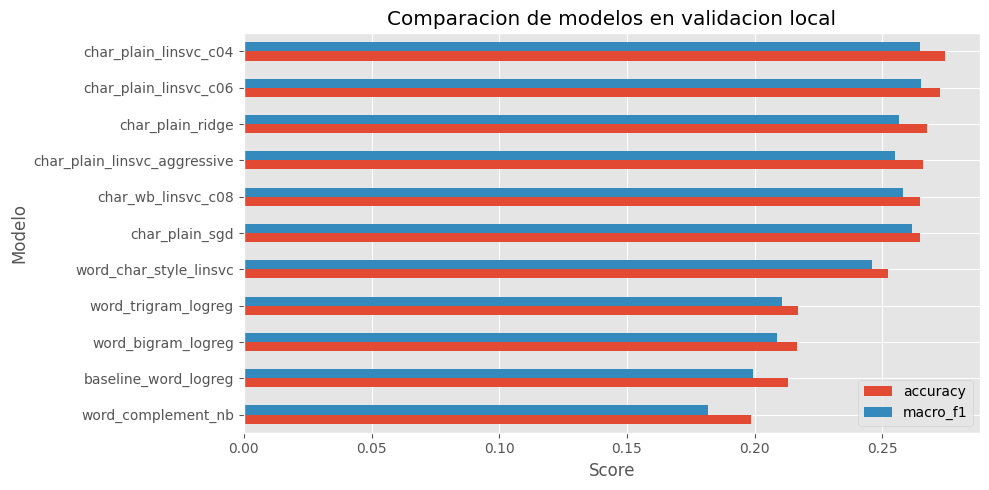

In [20]:
ax = results_df.sort_values("accuracy").plot(
    kind="barh",
    x="model_name",
    y=["accuracy", "macro_f1"],
    figsize=(10, 5),
    title="Comparacion de modelos en validacion local",
)
ax.set_xlabel("Score")
ax.set_ylabel("Modelo")
plt.tight_layout()
plt.show()


## 11. Seleccion del mejor modelo base


Escogemos primero el mejor modelo segun la validacion externa rapida, pero eso ya no decide el modelo final por si solo. Este ranking solo sirve para armar un shortlist por familia y luego comparar de forma consistente con validacion robusta por grupos.

In [21]:
def build_unique_family_shortlist(results_df, family_map, top_k):
    shortlist = []
    seen_families = set()

    for model_name in results_df['model_name']:
        family_name = family_map[model_name]
        if family_name in seen_families:
            continue
        shortlist.append(model_name)
        seen_families.add(family_name)
        if len(shortlist) >= top_k:
            break

    return shortlist


best_model_name = results_df.iloc[0]['model_name']
best_validation_score = results_df.iloc[0]
robust_shortlist_names = build_unique_family_shortlist(results_df, candidate_family_map, ROBUST_CV_TOP_K)

shortlist_df = results_df[results_df['model_name'].isin(robust_shortlist_names)].copy().reset_index(drop=True)
display(best_validation_score.to_frame(name='value'))
shortlist_df

,value
model_name,char_plain_linsvc_c04
model_family,char_plain_linsvc
accuracy,0.274479
macro_f1,0.264604
elapsed_seconds,81.506216


,model_name,model_family,accuracy,macro_f1,elapsed_seconds
0,char_plain_linsvc_c04,char_plain_linsvc,0.274479,0.264604,81.506216
1,char_plain_ridge,char_plain_ridge,0.267314,0.256515,155.932937
2,char_plain_linsvc_aggressive,char_plain_linsvc_aggressive,0.265881,0.254764,77.085133
3,char_plain_sgd,char_plain_sgd,0.264608,0.261392,74.431839


## 12. Analisis de errores del mejor modelo


Ademas del score global, conviene ver tres cosas:

1. Como le va por decada.
2. Que tan lejos se equivoca cuando falla.
3. Ejemplos concretos de errores grandes.

In [22]:
best_validation_predictions = validation_runs[best_model_name]["predictions"]

print(classification_report(y_valid, best_validation_predictions, zero_division=0))


              precision    recall  f1-score   support

         150       0.61      0.82      0.70       157
         151       0.52      0.78      0.62       163
         152       0.57      0.69      0.62       157
         153       0.60      0.70      0.65       155
         154       0.50      0.57      0.53       166
         155       0.39      0.37      0.38       167
         156       0.38      0.42      0.40       158
         157       0.27      0.33      0.30       165
         158       0.21      0.24      0.22       156
         159       0.26      0.27      0.26       160
         160       0.13      0.09      0.10       170
         161       0.18      0.15      0.16       157
         162       0.20      0.17      0.18       161
         163       0.18      0.14      0.16       166
         164       0.21      0.18      0.19       160
         165       0.18      0.15      0.17       163
         166       0.11      0.06      0.08       156
         167       0.20    

In [23]:
class_report_df = pd.DataFrame(classification_report(y_valid, best_validation_predictions, output_dict=True, zero_division=0)).T
per_decade_report_df = class_report_df.iloc[:-3].copy()
per_decade_report_df.index.name = 'decade'
per_decade_report_df = per_decade_report_df.reset_index().sort_values(['recall', 'precision'])
per_decade_report_df.head(10)

,decade,precision,recall,f1-score,support
16,166,0.112360,0.064103,0.081633,156.0
10,160,0.128205,0.088235,0.104530,170.0
35,185,0.102041,0.093168,0.097403,161.0
36,186,0.115646,0.109677,0.112583,155.0
37,187,0.134752,0.121019,0.127517,157.0
13,163,0.180451,0.144578,0.160535,166.0
11,161,0.178295,0.146497,0.160839,157.0
15,165,0.181159,0.153374,0.166113,163.0
24,174,0.178082,0.160494,0.168831,162.0
33,183,0.191176,0.164557,0.176871,158.0


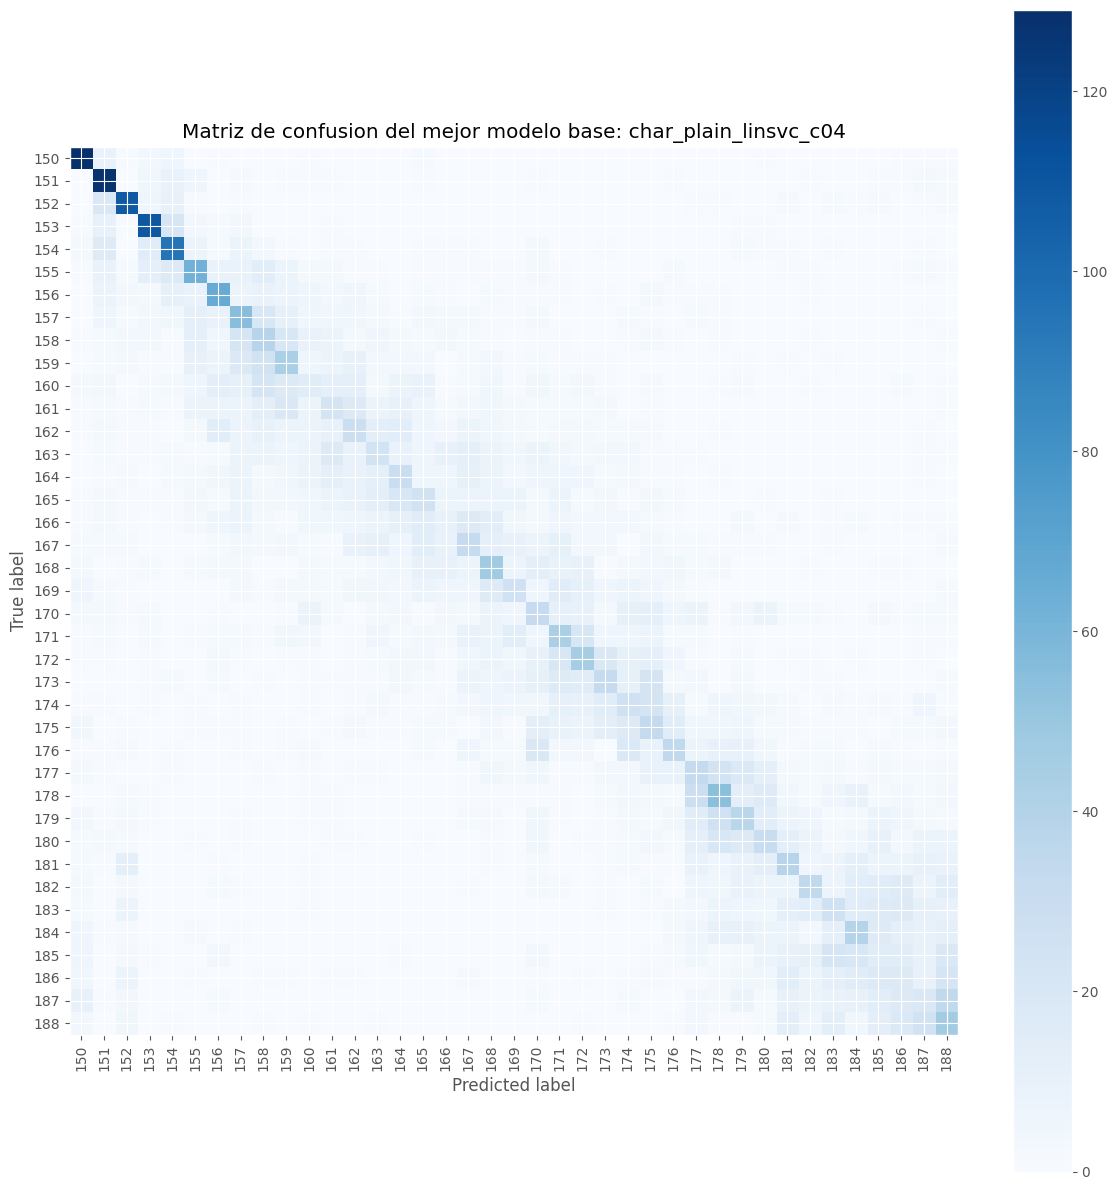

In [24]:
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    best_validation_predictions,
    xticks_rotation=90,
    include_values=False,
    cmap='Blues',
    ax=ax,
)
ax.set_title(f'Matriz de confusion del mejor modelo base: {best_model_name}')
plt.tight_layout()
plt.show()

In [25]:
error_analysis_df = X_valid.copy().reset_index(drop=True)
error_analysis_df['true_decade'] = y_valid.reset_index(drop=True)
error_analysis_df['predicted_decade'] = pd.Series(best_validation_predictions)
error_analysis_df['is_error'] = error_analysis_df['true_decade'] != error_analysis_df['predicted_decade']
error_analysis_df['distance'] = (error_analysis_df['true_decade'] - error_analysis_df['predicted_decade']).abs()

error_distance_df = (
    error_analysis_df.loc[error_analysis_df['is_error'], 'distance']
    .value_counts()
    .sort_index()
    .rename_axis('absolute_decade_distance')
    .reset_index(name='count')
)
if len(error_distance_df) > 0:
    error_distance_df['pct_of_errors'] = error_distance_df['count'] / error_distance_df['count'].sum()
else:
    error_distance_df['pct_of_errors'] = []

distance_tolerance_df = pd.DataFrame(
    {
        'max_absolute_distance': [1, 2, 3, 5],
        'pct_of_errors_within_tolerance': [
            error_analysis_df.loc[error_analysis_df['is_error'], 'distance'].le(max_distance).mean() if error_analysis_df['is_error'].any() else 0.0
            for max_distance in [1, 2, 3, 5]
        ],
        'pct_of_all_predictions_within_tolerance': [
            ((error_analysis_df['distance'] <= max_distance) & error_analysis_df['is_error']).mean()
            for max_distance in [1, 2, 3, 5]
        ],
    }
)

display(error_distance_df.head(10))
display(distance_tolerance_df)

error_examples_df = error_analysis_df[error_analysis_df['is_error']].sort_values('distance', ascending=False).head(10)
error_examples_df

,absolute_decade_distance,count,pct_of_errors
0,1,1023,0.224490
1,2,809,0.177529
2,3,564,0.123766
3,4,453,0.099408
4,5,331,0.072636
5,6,284,0.062322
6,7,180,0.039500
7,8,148,0.032478
8,9,110,0.024139
9,10,107,0.023480


,max_absolute_distance,pct_of_errors_within_tolerance,pct_of_all_predictions_within_tolerance
0,1,0.224490,0.162872
1,2,0.402019,0.291673
2,3,0.525785,0.381468
3,5,0.697828,0.506289


,text,true_decade,predicted_decade,is_error,distance
3474,"3° Carta annua de la vice- Provincia de Chile de los años 1611 \r\ny 1612, cuyo original está en la Biblioteca real de Madrid de la \r\npag 160 á 389 ...",188,150,True,38
569,"Herdoñana Antonio, Herrara Manuel, Hidalgo Igna- \r\ncio, Hinojosa Alfonso López de, Hortigoza Pedro, Hob- \r\ntell Lamberto, Hostin Jorge, Hurtasum Jaan.",188,150,True,38
3368,"Las minas consisten en las de plata del Talle de \r\nUspallasta, jurisdicción de Mendoza, y de exelente cali- \r\ndad-, pero han tenido muchas vicisitudes, ya por falta \r\nde ...",188,150,True,38
2850,"\r\nnos ha puesto en poder de la brava Gromadaza, mujer de \r\nFamongomadán, la cual, en venganza de su muerte de su marido e hijo, \r\nnos hace dar tales tormentos y tan cruel...",150,188,True,38
3318,"\r\n(1) Tengo delante dicha lista impresa (y su original manuscrito \r\ntambién ) , y no puedo menos de consignar con dolor que de los \r\n295 individuos ...",188,150,True,38
4557,"Relatione del Claríssimo Antonio Soriano, Oratore in Roma per !l' lllma. República di Venetia \r\nconcernenti la materia del Concilio di Trento.",150,187,True,37
4323,"sobre la carrera, del quadro en acá.» También se dijo qua- \r\ndrado, como aparece de otra escritura de 1224 del mismo \r\ncartuario: « Fació cambio cum ...",187,150,True,37
1061,"«S. B. el marqués de Valdespina, jefe \r\nde Estado mayor general del ejército real \r\ndel Norte, comandante de la columna de \r\noperaciones del Baztan y...",187,150,True,37
2713,"faclas, -15 Julio. \r\nDoña María Quindds y Villarroel, Condesa de Cumbres Al- \r\ntas, 31 de Octubre. \r\n18S0 Dofla María Flora Letnery Feírer, Marquesa d...",187,150,True,37
5908,"Finkb (Enrique). — XLI. 448: Sobre \r\nla historia de Bonifacio VIII y de \r\nlos Reyes de Aragón y Castilla, \r\nsus contemporáneos.",187,150,True,37


## 13. Validacion robusta y ajuste de hiperparametros


En clase se usa mucho `GridSearchCV`, asi que aqui dejamos una version alineada con eso pero metodologicamente consistente.

La regla de seleccion queda asi:

- el holdout externo con grupos se usa para screening rapido y para un chequeo final,
- la comparacion seria entre familias se hace con `StratifiedGroupKFold` sobre `X_train`,
- `GridSearchCV` se usa solo dentro de la familia ganadora por esa validacion robusta,
- y el holdout externo compara el representante base de esa familia contra su version tuneada.

Asi evitamos mezclar un `best_score_` de CV con un accuracy de holdout como si fueran equivalentes.

Para no congelar el notebook por defecto, este bloque se mantiene enfocado y usa `n_jobs = 1`, que en notebook sobre Windows suele ser la opcion mas estable.

In [26]:
robust_validation_runs = {}
robust_results_df = None
grid_search = None
cv_results_df = None
grid_best_score = None
grid_best_params = None
best_family_base_model_name = None
best_family_name = None
selected_model_name = best_model_name
selected_model_template = candidate_builders[best_model_name]()
selected_model_source = 'best_single_holdout_model'
selected_holdout_result = validation_runs[best_model_name]

robust_rows = []
for model_name in robust_shortlist_names:
    print(f'Validacion robusta para {model_name}...', flush=True)
    fold_results_df, summary = run_grouped_cv(candidate_builders[model_name](), X_train, y_train, train_groups, CV_SPLITS)
    robust_validation_runs[model_name] = {
        'fold_results_df': fold_results_df,
        **summary,
    }
    robust_rows.append(
        {
            'model_name': model_name,
            'model_family': candidate_family_map[model_name],
            **summary,
        }
    )
    print(
        f"  cv_accuracy={summary['cv_accuracy_mean']:.4f} +/- {summary['cv_accuracy_std']:.4f} | cv_macro_f1={summary['cv_macro_f1_mean']:.4f} +/- {summary['cv_macro_f1_std']:.4f}",
        flush=True,
    )

robust_results_df = pd.DataFrame(robust_rows).sort_values(
    ['cv_accuracy_mean', 'cv_macro_f1_mean'], ascending=False
).reset_index(drop=True)
display(robust_results_df)

best_family_base_model_name = robust_results_df.iloc[0]['model_name']
best_family_name = candidate_family_map[best_family_base_model_name]
selected_model_name = best_family_base_model_name
selected_model_template = candidate_builders[best_family_base_model_name]()
selected_model_source = 'best_family_by_grouped_cv'
selected_holdout_result = validation_runs[best_family_base_model_name]

if RUN_GRID_SEARCH:
    cv_strategy = StratifiedGroupKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_SEED)
    grid_pipeline = None
    param_grid = None

    if best_family_name == 'char_plain_linsvc':
        grid_pipeline = build_pipeline(
            text_mode='char',
            classifier=LinearSVC(C=0.4, max_iter=4000),
            cleaning_strategy='light',
            include_style_features=False,
            char_ngram_range=(2, 5),
            char_analyzer='char',
            char_min_df=3,
            char_max_features=CHAR_MAX_FEATURES,
        )
        param_grid = {
            'preprocessor__char_tfidf__min_df': [2, 3],
            'preprocessor__char_tfidf__max_features': [min(180_000, CHAR_MAX_FEATURES), CHAR_MAX_FEATURES],
            'classifier__C': [0.35, 0.4],
        }
    elif best_family_name == 'char_wb_linsvc':
        grid_pipeline = build_pipeline(
            text_mode='char_wb',
            classifier=LinearSVC(C=0.8, max_iter=4000),
            cleaning_strategy='light',
            include_style_features=False,
            char_ngram_range=(3, 5),
            char_max_features=CHAR_MAX_FEATURES,
        )
        param_grid = {
            'preprocessor__char_tfidf__ngram_range': [(3, 5), (3, 6)],
            'preprocessor__char_tfidf__max_features': [min(180_000, CHAR_MAX_FEATURES), CHAR_MAX_FEATURES],
            'classifier__C': [0.6, 0.8],
        }
    elif best_family_name == 'word_logreg':
        grid_pipeline = build_pipeline(
            text_mode='word',
            classifier=LogisticRegression(max_iter=1500, solver='saga', C=2.0, random_state=RANDOM_SEED),
            cleaning_strategy='light',
            include_style_features=False,
            word_ngram_range=(1, 2),
            word_min_df=2,
            word_max_df=0.97,
            word_sublinear_tf=True,
            word_binary=False,
            word_max_features=WORD_MAX_FEATURES,
        )
        param_grid = {
            'preprocessor__word_tfidf__ngram_range': [(1, 2), (1, 3)],
            'preprocessor__word_tfidf__min_df': [2, 3],
            'preprocessor__word_tfidf__max_df': [0.96, 0.97],
            'classifier__C': [1.5, 2.0],
        }
    elif best_family_name == 'char_plain_sgd':
        grid_pipeline = build_pipeline(
            text_mode='char',
            classifier=SGDClassifier(loss='hinge', alpha=1e-5, max_iter=2500, tol=1e-3, random_state=RANDOM_SEED),
            cleaning_strategy='light',
            include_style_features=False,
            char_ngram_range=(2, 5),
            char_analyzer='char',
            char_min_df=2,
            char_max_features=CHAR_MAX_FEATURES,
        )
        param_grid = {
            'preprocessor__char_tfidf__min_df': [2, 3],
            'classifier__alpha': [5e-6, 1e-5, 2e-5],
        }

    if grid_pipeline is None:
        print(f'No hay grid search reducido configurado para la familia {best_family_name}. Se conserva el representante base.')
    else:
        grid_search = GridSearchCV(
            estimator=grid_pipeline,
            param_grid=param_grid,
            scoring='accuracy',
            cv=cv_strategy,
            n_jobs=GRIDSEARCH_N_JOBS,
            refit=True,
            verbose=1,
        )

        grid_search.fit(X_train, y_train, groups=train_groups)
        cv_results_df = pd.DataFrame(grid_search.cv_results_).sort_values(['rank_test_score', 'mean_test_score'], ascending=[True, False]).reset_index(drop=True)
        grid_best_score = grid_search.best_score_
        grid_best_params = grid_search.best_params_

        display_columns = ['rank_test_score', 'mean_test_score', 'std_test_score'] + [column for column in cv_results_df.columns if column.startswith('param_')]
        display(cv_results_df[display_columns].head(10))
        print('Mejores hiperparametros:', grid_best_params)
        print('Mejor score CV dentro de la familia:', round(grid_best_score, 4))

        tuned_holdout_result = evaluate_model(clone(grid_search.best_estimator_), X_train, y_train, X_valid, y_valid)
        base_holdout_result = validation_runs[best_family_base_model_name]
        print(
            f"Holdout base de la familia: accuracy={base_holdout_result['accuracy']:.4f} | macro_f1={base_holdout_result['macro_f1']:.4f}"
        )
        print(
            f"Holdout tuneado en la misma familia: accuracy={tuned_holdout_result['accuracy']:.4f} | macro_f1={tuned_holdout_result['macro_f1']:.4f}"
        )

        if is_better_result(tuned_holdout_result, base_holdout_result):
            selected_model_name = f'{best_family_base_model_name}__gridsearch'
            selected_model_template = clone(grid_search.best_estimator_)
            selected_model_source = 'grid_search_improved_holdout_within_best_family'
            selected_holdout_result = tuned_holdout_result
        else:
            print('La version tuneada no mejoro de forma consistente al representante base. Se conserva el modelo base de la familia.')
else:
    print('RUN_GRID_SEARCH esta en False. Se conserva el mejor modelo por validacion robusta.')

Validacion robusta para char_plain_linsvc_c04...
  cv_accuracy=0.2686 +/- 0.0045 | cv_macro_f1=0.2583 +/- 0.0040
Validacion robusta para char_plain_ridge...
  cv_accuracy=0.2618 +/- 0.0034 | cv_macro_f1=0.2510 +/- 0.0029
Validacion robusta para char_plain_linsvc_aggressive...
  cv_accuracy=0.2574 +/- 0.0046 | cv_macro_f1=0.2465 +/- 0.0039
Validacion robusta para char_plain_sgd...
  cv_accuracy=0.2553 +/- 0.0037 | cv_macro_f1=0.2520 +/- 0.0040


,model_name,model_family,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_elapsed_seconds_mean
0,char_plain_linsvc_c04,char_plain_linsvc,0.268569,0.004505,0.258276,0.003974,91.128676
1,char_plain_ridge,char_plain_ridge,0.261802,0.003403,0.250952,0.002915,130.981671
2,char_plain_linsvc_aggressive,char_plain_linsvc_aggressive,0.257424,0.004590,0.246527,0.003907,92.724980
3,char_plain_sgd,char_plain_sgd,0.255314,0.003677,0.252049,0.003996,80.886949


Fitting 5 folds for each of 8 candidates, totalling 40 fits


,rank_test_score,mean_test_score,std_test_score,param_classifier__C,param_preprocessor__char_tfidf__max_features,param_preprocessor__char_tfidf__min_df
0,1,0.268808,0.004141,0.40,220000,2
1,2,0.268689,0.003852,0.35,220000,2
2,3,0.268569,0.004505,0.40,220000,3
3,4,0.268291,0.003799,0.35,180000,3
4,5,0.268012,0.003991,0.40,180000,2
5,6,0.267932,0.003796,0.40,180000,3
6,7,0.267932,0.004035,0.35,220000,3
7,8,0.267893,0.004160,0.35,180000,2


Mejores hiperparametros: {'classifier__C': 0.4, 'preprocessor__char_tfidf__max_features': 220000, 'preprocessor__char_tfidf__min_df': 2}
Mejor score CV dentro de la familia: 0.2688
Holdout base de la familia: accuracy=0.2745 | macro_f1=0.2646
Holdout tuneado en la misma familia: accuracy=0.2754 | macro_f1=0.2659


## 14. Modelo final elegido


El modelo final ya no sale de mezclar `best_score_` de CV con accuracy de holdout. Primero elegimos la mejor familia con validacion robusta por grupos. Luego, si hay grid, afinamos solo esa familia y contrastamos su version tuneada contra la version base en el holdout externo.

In [27]:
selected_model_summary_df = pd.DataFrame(
    {
        'best_holdout_model_name': [best_model_name],
        'best_holdout_accuracy': [validation_runs[best_model_name]['accuracy']],
        'best_family_by_grouped_cv': [best_family_base_model_name],
        'best_family_cv_accuracy_mean': [robust_results_df.iloc[0]['cv_accuracy_mean']],
        'best_family_cv_accuracy_std': [robust_results_df.iloc[0]['cv_accuracy_std']],
        'selected_model_name': [selected_model_name],
        'selected_model_source': [selected_model_source],
        'selected_holdout_accuracy': [selected_holdout_result['accuracy']],
        'selected_holdout_macro_f1': [selected_holdout_result['macro_f1']],
        'grid_search_best_score': [grid_best_score],
    }
)
selected_model_summary_df

,best_holdout_model_name,best_holdout_accuracy,best_family_by_grouped_cv,best_family_cv_accuracy_mean,best_family_cv_accuracy_std,selected_model_name,selected_model_source,selected_holdout_accuracy,selected_holdout_macro_f1,grid_search_best_score
0,char_plain_linsvc_c04,0.274479,char_plain_linsvc_c04,0.268569,0.004505,char_plain_linsvc_c04__gridsearch,grid_search_improved_holdout_within_best_family,0.275434,0.265857,0.268808


## 15. Entrenamiento final con todo `train.csv`


Una vez elegido el mejor enfoque, lo reentrenamos usando todo el conjunto de entrenamiento. Ese es el modelo que luego se guarda y se usa para predecir `eval.csv`.


In [28]:
print(f'Entrenando modelo final: {selected_model_name}')
train_start = time.time()
final_model = clone(selected_model_template)
final_model.fit(X_full, y_full)
train_elapsed = time.time() - train_start
print(f'Tiempo de entrenamiento final: {train_elapsed:.1f} segundos')
final_model

Entrenando modelo final: char_plain_linsvc_c04__gridsearch
Tiempo de entrenamiento final: 100.8 segundos


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_builder', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001A3027194E0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arg

## 16. Guardado del modelo


El enunciado pide guardar el modelo final de `scikit-learn` usando `pickle` o `joblib`. Aqui usamos `joblib`.

El notebook no crea carpetas nuevas. Si `models/` o `data/submissions/` ya existen en el proyecto, se reutilizan; si no, los artefactos se guardan con nombres simples en la raiz del proyecto.

In [33]:
model_path = MODEL_OUTPUT_DIR / 'modelo_final_8_abril.joblib'
joblib.dump(final_model, model_path)
reloaded_model = joblib.load(model_path)
serialization_check = np.array_equal(
    final_model.predict(X_full.head(25)),
    reloaded_model.predict(X_full.head(25)),
)

pd.DataFrame(
    {
        'artifact': ['final_model'],
        'relative_path': [str(model_path.relative_to(PROJECT_ROOT)) if model_path != PROJECT_ROOT else model_path.name],
        'reload_prediction_check': [serialization_check],
    }
)

,artifact,relative_path,reload_prediction_check
0,final_model,models\modelo_final_8_abril.joblib,True


## 17. Prediccion sobre `eval.csv`


Solo en este punto usamos `eval.csv`, una vez terminado el entrenamiento.


In [30]:
prediction_start = time.time()
eval_predictions = final_model.predict(X_eval)
prediction_elapsed = time.time() - prediction_start
print(f"Tiempo de prediccion en eval.csv: {prediction_elapsed:.1f} segundos")

eval_predictions[:10]


Tiempo de prediccion en eval.csv: 6.2 segundos


array([173, 185, 150, 169, 153, 174, 170, 157, 161, 152])

## 18. Generacion del submission para Kaggle


El archivo final debe tener exactamente dos columnas:

- `id`
- `answer`

Aqui lo guardamos con un nombre simple y sin crear carpetas nuevas. Si ya existe una carpeta de submissions en el proyecto, se reutiliza; si no, el CSV queda en la raiz.

In [31]:
submission_df = pd.DataFrame(
    {
        'id': eval_df['id'].astype(int),
        'answer': pd.Series(eval_predictions).astype(int),
    }
)

submission_path = SUBMISSION_OUTPUT_DIR / 'entrega_kaggle_competencia.csv'
submission_df.to_csv(submission_path, index=False)

display(submission_df.head())
print(submission_path)

,id,answer
0,0,173
1,1,185
2,2,150
3,3,169
4,4,153


C:\Users\userr\Proyecto-Machine_learning\data\submissions\entrega_kaggle_competencia.csv


## 19. Generacion opcional de cinco envios


La competencia pide al menos cinco envios diferentes para que la participacion sea valida. Esta celda queda opcional de verdad: solo se ejecuta si `RUN_FIVE_SUBMISSIONS = True`, no crea manifests auxiliares y solo genera hasta cinco CSVs utiles.

In [32]:
generated_submission_rows = []

if RUN_FIVE_SUBMISSIONS:
    submission_model_names = [selected_model_name]
    for model_name in results_df['model_name']:
        if model_name not in submission_model_names:
            submission_model_names.append(model_name)
        if len(submission_model_names) == 5:
            break

    for upload_order, model_name in enumerate(submission_model_names, start=1):
        print(f'Generando submission {upload_order}/5 para {model_name}...', flush=True)

        if model_name == selected_model_name:
            model = final_model
        else:
            model = candidate_builders[model_name]()
            model.fit(X_full, y_full)

        current_submission = pd.DataFrame(
            {
                'id': eval_df['id'].astype(int),
                'answer': pd.Series(model.predict(X_eval)).astype(int),
            }
        )

        safe_model_name = model_name.replace('__', '_').replace('/', '_')
        output_path = SUBMISSION_OUTPUT_DIR / f'submission_{upload_order:02d}_{safe_model_name}.csv'
        current_submission.to_csv(output_path, index=False)

        generated_submission_rows.append(
            {
                'upload_order': upload_order,
                'model_name': model_name,
                'submission_path': str(output_path.relative_to(PROJECT_ROOT)) if output_path != PROJECT_ROOT else output_path.name,
            }
        )

    pd.DataFrame(generated_submission_rows)
else:
    print('RUN_FIVE_SUBMISSIONS esta en False. No se generaron envios adicionales.')

RUN_FIVE_SUBMISSIONS esta en False. No se generaron envios adicionales.


## 20. Conclusiones


En esta version del notebook:

- mantenemos la estructura original por secciones, pero corregimos la validacion para evitar leakage por textos duplicados,
- comparamos limpieza `light` contra `aggressive` y dejamos `light` como estrategia principal porque conserva mejor la senal historica,
- ampliamos la comparacion de modelos clasicos dentro de `scikit-learn` con candidatos lineales y Naive Bayes razonables,
- analizamos errores por decada, matriz de confusion y distancia entre decada real y predicha,
- usamos validacion robusta con `StratifiedGroupKFold` para elegir la familia de modelos,
- usamos `GridSearchCV` solo dentro de la familia ganadora y contrastamos esa version tuneada contra el holdout externo,
- entrenamos un unico modelo final con todo `train.csv`,
- lo guardamos en `joblib`,
- y generamos el submission final sin crear carpetas nuevas.

La conclusion importante es esta: en este problema, la mejora fuerte no vino de limpiar mas agresivamente ni de agregar complejidad por agregarla. Vino de controlar mejor el leakage, conservar la senal historica util del OCR y explotar n-gramas de caracteres con un clasificador lineal robusto.